Version 1.0.1

# Pandas basics 

Hi! In this programming assignment you need to refresh your `pandas` knowledge. You will need to do several [`groupby`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.groupby.html)s and [`join`]()`s to solve the task. 

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline 

from grader import Grader

In [2]:
ls ..\readonly\final_project_data

 Volume in drive C is Windows
 Volume Serial Number is 987B-21F2

 Directory of C:\Users\vorapolbig\Projects\competitive-data-science\readonly\final_project_data

15/01/2020  09:48 PM    <DIR>          .
15/01/2020  09:48 PM    <DIR>          ..
15/12/2019  10:01 PM             3,573 item_categories.csv
15/12/2019  10:01 PM         1,568,417 items.csv
15/12/2019  10:01 PM        94,603,866 sales_train.csv
15/12/2019  10:01 PM         2,245,108 sample_submission.csv
15/12/2019  10:01 PM             2,977 shops.csv
15/12/2019  10:01 PM         3,182,735 test.csv
               6 File(s)    101,606,676 bytes
               2 Dir(s)  39,885,348,864 bytes free


In [27]:
DATA_FOLDER = '../readonly/final_project_data/'

transactions    = pd.read_csv(os.path.join(DATA_FOLDER, 'sales_train.csv'))
items           = pd.read_csv(os.path.join(DATA_FOLDER, 'items.csv'))
item_categories = pd.read_csv(os.path.join(DATA_FOLDER, 'item_categories.csv'))
shops           = pd.read_csv(os.path.join(DATA_FOLDER, 'shops.csv'))

The dataset we are going to use is taken from the competition, that serves as the final project for this course. You can find complete data description at the [competition web page](https://www.kaggle.com/c/competitive-data-science-final-project/data). To join the competition use [this link](https://www.kaggle.com/t/1ea93815dca248e99221df42ebde3540).

## Grading

We will create a grader instace below and use it to collect your answers. When function `submit_tag` is called, grader will store your answer *locally*. The answers will *not* be submited to the platform immediately so you can call `submit_tag` function as many times as you need. 

When you are ready to push your answers to the platform you should fill your credentials and run `submit` function in the <a href="#Authorization-&-Submission">last paragraph</a>  of the assignment.

In [28]:
grader = Grader()

# Task

Let's start with a simple task. 

<ol start="0">
  <li><b>Print the shape of the loaded dataframes and use [`df.head`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.head.html) function to print several rows. Examine the features you are given.</b></li>
</ol>

In [29]:
# YOUR CODE GOES HERE
transactions.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0


In [31]:
items.head()

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


In [7]:
item_categories.head()

,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


In [8]:
shops.head()

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


Now use your `pandas` skills to get answers for the following questions. 
The first question is:

1. ** What was the maximum total revenue among all the shops in September, 2014?** 


* Hereinafter *revenue* refers to total sales minus value of goods returned.

*Hints:*

* Sometimes items are returned, find such examples in the dataset. 
* It is handy to split `date` field into [`day`, `month`, `year`] components and use `df.year == 14` and `df.month == 9` in order to select target subset of dates.
* You may work with `date` feature as with srings, or you may first convert it to `pd.datetime` type with `pd.to_datetime` function, but do not forget to set correct `format` argument.

In [9]:
df = transactions
df['datetime'] = pd.to_datetime(transactions.date, dayfirst=True)

In [10]:
df2 = df[(df['datetime'] >= '2014-9-1') & (df['datetime'] <= '2014-9-30')]
df2['revenue'] = df2.item_price * df2.item_cnt_day

C:\Users\vorapolbig\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [52]:
df2.groupby(by=['shop_id']).sum().revenue.max()

7982852.199999956

In [53]:
# YOUR CODE GOES HERE

max_revenue = df2.groupby(by=['shop_id']).sum().revenue.max() # PUT YOUR ANSWER IN THIS VARIABLE
grader.submit_tag('max_revenue', max_revenue)

Current answer for task max_revenue is: 7982852.199999956


Great! Let's move on and answer another question:

<ol start="2">
  <li><b>What item category generated the highest revenue in summer 2014?</b></li>
</ol>

* Submit `id` of the category found.
    
* Here we call "summer" the period from June to August.

*Hints:*

* Note, that for an object `x` of type `pd.Series`: `x.argmax()` returns **index** of the maximum element. `pd.Series` can have non-trivial index (not `[1, 2, 3, ... ]`).

In [54]:
df_summer = df[(df['datetime'] >= '2014-6-1') & (df['datetime'] <= '2014-8-31')]
df_summer['revenue'] = df_summer['item_price'] * df_summer['item_cnt_day'] 
df_summer

C:\Users\vorapolbig\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,datetime,revenue
1705909,15.06.2014,17,26,9532,399.00,1.0,2014-06-15,399.00
1705910,10.06.2014,17,26,9507,149.00,1.0,2014-06-10,149.00
1705911,13.06.2014,17,26,9509,246.32,1.0,2014-06-13,246.32
1705912,03.06.2014,17,26,9532,399.00,1.0,2014-06-03,399.00
1705913,08.06.2014,17,26,9532,399.00,1.0,2014-06-08,399.00
...,...,...,...,...,...,...,...,...
1953686,16.08.2014,19,27,2770,999.00,1.0,2014-08-16,999.00
1953687,15.08.2014,19,27,2769,999.00,1.0,2014-08-15,999.00
1953688,01.08.2014,19,27,2585,1249.00,1.0,2014-08-01,1249.00
1953689,30.08.2014,19,27,2578,299.00,1.0,2014-08-30,299.00


In [55]:
df3 = pd.merge(df_summer, items, on='item_id')
# df_summer.merge(items, how='left',left_on='item_id')
df3

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,datetime,revenue,item_name,item_category_id
0,15.06.2014,17,26,9532,399.00,1.0,2014-06-15,399.00,"В тылу врага: Штурм 2 [PC, Jewel, русская версия]",30
1,03.06.2014,17,26,9532,399.00,1.0,2014-06-03,399.00,"В тылу врага: Штурм 2 [PC, Jewel, русская версия]",30
2,08.06.2014,17,26,9532,399.00,1.0,2014-06-08,399.00,"В тылу врага: Штурм 2 [PC, Jewel, русская версия]",30
3,11.06.2014,17,26,9532,399.00,1.0,2014-06-11,399.00,"В тылу врага: Штурм 2 [PC, Jewel, русская версия]",30
4,19.06.2014,17,26,9532,399.00,1.0,2014-06-19,399.00,"В тылу врага: Штурм 2 [PC, Jewel, русская версия]",30
...,...,...,...,...,...,...,...,...,...,...
247777,12.08.2014,19,27,5258,399.50,1.0,2014-08-12,399.50,"Need for Speed The Run (Essentials) [PS3, русс...",19
247778,23.08.2014,19,27,1666,1049.00,1.0,2014-08-23,1049.00,BENSON GEORGE Giblet Gravy LP,58
247779,03.08.2014,19,27,1211,1549.00,1.0,2014-08-03,1549.00,AC/DC Fly On The Wall Limited Edition LP,58
247780,11.08.2014,19,27,2450,555.06,1.0,2014-08-11,555.06,"Crysis 3. Hunter Edition [Xbox 360, русская ве...",23


In [56]:
df3.groupby(by=['item_category_id']).sum().revenue.idxmax()

20

In [57]:
# YOUR CODE GOES HERE
category_id_with_max_revenue = df3.groupby(by=['item_category_id']).sum().revenue.idxmax() # PUT YOUR ANSWER IN THIS VARIABLE
grader.submit_tag('category_id_with_max_revenue', category_id_with_max_revenue)

Current answer for task category_id_with_max_revenue is: 20


<ol start="3">
  <li><b>How many items are there, such that their price stays constant (to the best of our knowledge) during the whole period of time?</b></li>
</ol>

* Let's assume, that the items are returned for the same price as they had been sold.

In [78]:
transactions.groupby(by=['item_id']).nunique().item_price.value_counts().max()

5926

In [79]:
# YOUR CODE GOES HERE

num_items_constant_price =transactions.groupby(by=['item_id']).nunique().item_price.value_counts().max() # PUT YOUR ANSWER IN THIS VARIABLE
grader.submit_tag('num_items_constant_price', num_items_constant_price)

Current answer for task num_items_constant_price is: 5926


Remember, the data can sometimes be noisy.

<ol start="4">
  <li><b>What was the variance of the number of sold items per day sequence for the shop with `shop_id = 25` in December, 2014?</b></li>
</ol>

* Fill `total_num_items_sold` and `days` arrays, and plot the sequence with the code below.
* Then compute variance. Remember, there can be differences in how you normalize variance (biased or unbiased estimate, see [link](https://math.stackexchange.com/questions/496627/the-difference-between-unbiased-biased-estimator-variance)). Compute ***unbiased*** estimate (use the right value for `ddof` argument in `pd.var` or `np.var`).

In [94]:
dec14_25.loc[dec14_25.item_cnt_day == -1,]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,datetime
2320516,06.12.2014,23,25,3584,1449.0,-1.0,2014-12-06
2322598,06.12.2014,23,25,8448,4090.0,-1.0,2014-12-06
2321199,06.12.2014,23,25,2637,1599.0,-1.0,2014-12-06
2319563,07.12.2014,23,25,16017,389.0,-1.0,2014-12-07
2320739,14.12.2014,23,25,4997,3199.0,-1.0,2014-12-14
2320486,18.12.2014,23,25,3557,1999.0,-1.0,2014-12-18
2321485,21.12.2014,23,25,3461,2599.0,-1.0,2014-12-21
2320292,21.12.2014,23,25,3933,2099.0,-1.0,2014-12-21
2321137,24.12.2014,23,25,2875,849.0,-1.0,2014-12-24
2318777,25.12.2014,23,25,20831,1999.0,-1.0,2014-12-25


In [80]:
dec_2014 = df[(df['datetime'] >= '2014-12-1') & (df['datetime'] <= '2014-12-31')]
dec14_25 = dec_2014.loc[dec_2014['shop_id'] == 25,]

In [99]:
dec14_25.sort_values(by='datetime', inplace=True, ascending=True)
dec14_25.groupby(by='datetime').sum().item_cnt_day.var()

C:\Users\vorapolbig\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


117167.70229885059

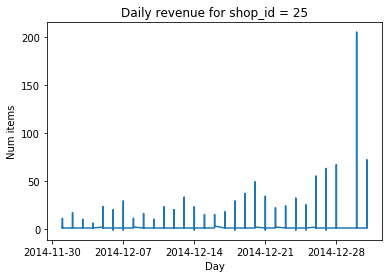

Current answer for task total_num_items_sold_var is: 117167.70229885059


In [100]:
shop_id = 25

total_num_items_sold = dec14_25.item_cnt_day # YOUR CODE GOES HERE
days = dec14_25.datetime # YOUR CODE GOES HERE

# Plot it
plt.plot(days, total_num_items_sold)
plt.ylabel('Num items')
plt.xlabel('Day')
plt.title("Daily revenue for shop_id = 25")
plt.show()

total_num_items_sold_var = dec14_25.groupby(by='datetime').sum().item_cnt_day.var() # PUT YOUR ANSWER IN THIS VARIABLE
grader.submit_tag('total_num_items_sold_var', total_num_items_sold_var)

## Authorization & Submission
To submit assignment to Cousera platform, please, enter your e-mail and token into the variables below. You can generate token on the programming assignment page. *Note:* Token expires 30 minutes after generation.

In [104]:
STUDENT_EMAIL = 'vorapolbig@gmail.com'# EMAIL HERE
STUDENT_TOKEN = 'ygLKDQsFamc0GZdw'# TOKEN HERE
grader.status()

You want to submit these numbers:
Task max_revenue: 7982852.199999956
Task category_id_with_max_revenue: 20
Task num_items_constant_price: 5926
Task total_num_items_sold_var: 117167.70229885059


In [105]:
grader.submit(STUDENT_EMAIL, STUDENT_TOKEN)

Submitted to Coursera platform. See results on assignment page!


Well done! :)